# 03 - Shared Baseline Backtest

## Purpose of this notebook

In this notebook, I run the first full backtest of the tactical ETF allocation strategy.

The goal is to take the signal artifacts from Notebook 02 and turn them into an actual portfolio simulation. This allows me to evaluate whether the baseline strategy is promising before moving on to more advanced tuning approaches.

## What this notebook will do

This notebook will:
- load the monthly momentum, trend filter, and volatility signals
- construct monthly portfolio weights
- apply those weights to next-month returns
- calculate strategy performance over time
- compare different shared momentum windows
- compare the strategy against benchmark portfolios
- evaluate results across train, validation, and test periods

## Baseline strategy definition

At each monthly decision date, the strategy will:
1. rank ETFs by momentum
2. keep only ETFs above their 200-day moving average
3. select the top 2 eligible ETFs
4. assign weights using inverse volatility
5. if fewer than 2 ETFs qualify, allocate remaining weight to IEF
6. apply the chosen weights to the following month's return

## Why this notebook matters

This is the first notebook where I can answer whether the strategy is actually useful from a portfolio perspective. A signal may look reasonable on paper, but it still has to produce good performance, acceptable drawdowns, and believable out-of-sample behavior.

## 2. Import libraries

In this section, I import the libraries needed for the backtest.

### What this section is doing
These imports support:
- working with time-series data
- numerical calculations
- charting strategy performance
- reading saved signal artifacts

### What I can change later
- I can later move reusable functions into `src/`
- I can add plotly or seaborn later if I want more advanced visualizations

### What to expect
This section should run quietly if the environment is set up correctly.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Load processed data and signal artifacts

In this section, I load the monthly return data and the signal tables created in Notebook 02.

### What this section is doing
I load:
- monthly returns
- monthly moving average filter
- monthly rolling volatility
- monthly momentum tables for each tested lookback window

### Why this matters
These files provide everything needed to simulate the strategy:
- momentum tells me what is strong
- the MA filter tells me what is eligible
- volatility tells me how to size positions
- monthly returns let me calculate realized portfolio performance

### What I can change later
- I can later load benchmark files or additional features if needed
- I can switch to Parquet if I want faster file loading

### What to expect
I should see clean tables with matching monthly indexes and ETF columns.

In [5]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)
ma_filter_monthly = pd.read_csv(PROCESSED_DIR / "ma_filter_monthly.csv", index_col=0, parse_dates=True)
rolling_vol_monthly = pd.read_csv(PROCESSED_DIR / "rolling_vol_monthly.csv", index_col=0, parse_dates=True)

momentum_60 = pd.read_csv(PROCESSED_DIR / "momentum_60d_monthly.csv", index_col=0, parse_dates=True)
momentum_120 = pd.read_csv(PROCESSED_DIR / "momentum_120d_monthly.csv", index_col=0, parse_dates=True)
momentum_180 = pd.read_csv(PROCESSED_DIR / "momentum_180d_monthly.csv", index_col=0, parse_dates=True)
momentum_252 = pd.read_csv(PROCESSED_DIR / "momentum_252d_monthly.csv", index_col=0, parse_dates=True)

momentum_tables = {
    60: momentum_60,
    120: momentum_120,
    180: momentum_180,
    252: momentum_252,
}

print("Monthly returns:", monthly_returns.shape)
print("MA filter:", ma_filter_monthly.shape)
print("Rolling vol:", rolling_vol_monthly.shape)
for k, v in momentum_tables.items():
    print(f"Momentum {k}d:", v.shape)

Monthly returns: (253, 8)
MA filter: (242, 8)
Rolling vol: (242, 8)
Momentum 60d: (242, 8)
Momentum 120d: (242, 8)
Momentum 180d: (242, 8)
Momentum 252d: (242, 8)


## 4. Define the split and backtest settings

In this section, I define the research periods and key backtest settings.

### What this section is doing
I define:
- train / validation / test dates
- top K
- fallback asset
- momentum windows to compare

### Why this matters
I want the backtest to be consistent with the rigorous evaluation framework chosen earlier.

### What I can change later
- I can test top 3 later
- I can change the fallback asset later
- I can later compare equal weight vs inverse-vol weighting

In [6]:
TRAIN_START = "2005-01-01"
TRAIN_END = "2014-12-31"

VALID_START = "2015-01-01"
VALID_END = "2018-12-31"

TEST_START = "2019-01-01"
TEST_END = monthly_returns.index.max().strftime("%Y-%m-%d")

TOP_K = 2
FALLBACK_ASSET = "IEF"
MOMENTUM_WINDOWS = [60, 120, 180, 252]

print("Top K:", TOP_K)
print("Fallback asset:", FALLBACK_ASSET)
print("Momentum windows:", MOMENTUM_WINDOWS)

Top K: 2
Fallback asset: IEF
Momentum windows: [60, 120, 180, 252]


## 5. Align all tables to a common monthly index

In this section, I make sure all strategy inputs use the same monthly decision dates.

### What this section is doing
I intersect the indexes across:
- monthly returns
- MA filter
- rolling volatility
- all momentum tables

### Why this matters
If the tables do not line up exactly, the backtest can use inconsistent dates or accidentally mismatch signals and returns.

### What I can change later
- If I add new signals later, I should include them in this alignment step

In [7]:
common_index = monthly_returns.index.intersection(ma_filter_monthly.index).intersection(rolling_vol_monthly.index)

for window in MOMENTUM_WINDOWS:
    common_index = common_index.intersection(momentum_tables[window].index)

common_index = common_index.sort_values()

monthly_returns = monthly_returns.loc[common_index]
ma_filter_monthly = ma_filter_monthly.loc[common_index]
rolling_vol_monthly = rolling_vol_monthly.loc[common_index]
for window in MOMENTUM_WINDOWS:
    momentum_tables[window] = momentum_tables[window].loc[common_index]

print("Common monthly observations:", len(common_index))
print("First date:", common_index.min())
print("Last date:", common_index.max())

Common monthly observations: 242
First date: 2006-01-31 00:00:00
Last date: 2026-02-27 00:00:00


## 6. Helper functions

In this section, I define reusable functions for:
- splitting data by date
- computing inverse-volatility weights
- generating portfolio weights from the strategy rules
- computing performance metrics

### Why this matters
These functions keep the notebook cleaner and make the backtest logic easier to understand and test.

### What I can change later
- Once these functions are stable, I can move them into `src/`
- I can later add transaction costs or turnover into the backtest functions

In [8]:
def split_by_date(df, train_start, train_end, valid_start, valid_end, test_start, test_end):
    train = df.loc[train_start:train_end].copy()
    valid = df.loc[valid_start:valid_end].copy()
    test = df.loc[test_start:test_end].copy()
    return train, valid, test


def inverse_vol_weights(vol_series):
    vol_series = vol_series.replace(0, np.nan).dropna()
    if len(vol_series) == 0:
        return pd.Series(dtype=float)
    inv_vol = 1 / vol_series
    return inv_vol / inv_vol.sum()


def compute_metrics(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return {}

    cumulative = (1 + return_series).cumprod()
    total_months = len(return_series)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = return_series.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }

## 7. Build the portfolio weight engine

In this section, I define the rules that convert signals into monthly portfolio weights.

### What this section is doing
For a given month, the strategy:
1. looks at momentum scores
2. filters out ETFs below their 200-day moving average
3. ranks the remaining ETFs
4. keeps the top K
5. weights them using inverse volatility
6. allocates any leftover weight to the fallback asset

### Why this matters
This is the core portfolio construction logic of the shared baseline.

### Important note
These are the weights decided at the current month-end. In the next section, I will shift them forward by one month before applying returns so that the backtest does not use future information.

### What I can change later
- I can compare equal-weight vs inverse-vol
- I can test a different fallback rule
- I can later include transaction cost penalties

In [9]:
def generate_weight_table(momentum_df, ma_filter_df, vol_df, top_k=2, fallback_asset="IEF"):
    assets = momentum_df.columns.tolist()
    weight_records = []

    for dt in momentum_df.index:
        momentum_today = momentum_df.loc[dt]
        ma_today = ma_filter_df.loc[dt]
        vol_today = vol_df.loc[dt]

        weights = pd.Series(0.0, index=assets)

        eligible = momentum_today[ma_today].dropna().sort_values(ascending=False)
        selected_assets = eligible.head(top_k).index.tolist()

        if len(selected_assets) > 0:
            selected_vol = vol_today.loc[selected_assets].dropna()
            selected_weights = inverse_vol_weights(selected_vol)

            for asset, w in selected_weights.items():
                weights[asset] = w

        weight_sum = weights.sum()

        if weight_sum < 1.0:
            weights[fallback_asset] += (1.0 - weight_sum)

        weight_records.append(weights)

    weight_table = pd.DataFrame(weight_records, index=momentum_df.index)
    return weight_table

## 8. Generate weight tables for each momentum window

In this section, I create a monthly weight table for each shared momentum lookback window.

### What this section is doing
I run the portfolio construction logic separately for:
- 60-day momentum
- 120-day momentum
- 180-day momentum
- 252-day momentum

### Why this matters
This lets me compare different shared signal horizons while keeping the rest of the strategy fixed.

### What I can change later
- I can add more lookback windows later
- I can store the selection table separately if I want more diagnostics

In [10]:
weight_tables = {}

for window in MOMENTUM_WINDOWS:
    weight_tables[window] = generate_weight_table(
        momentum_df=momentum_tables[window],
        ma_filter_df=ma_filter_monthly,
        vol_df=rolling_vol_monthly,
        top_k=TOP_K,
        fallback_asset=FALLBACK_ASSET,
    )

for window in MOMENTUM_WINDOWS:
    print(f"Weight table {window}d:", weight_tables[window].shape)

display(weight_tables[120].head())

Weight table 60d: (242, 8)
Weight table 120d: (242, 8)
Weight table 180d: (242, 8)
Weight table 252d: (242, 8)


,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
2006-01-31,0.499743,0.000000,0.500257,0.0,0.0,0.0,0.0,0.0
2006-02-28,0.489035,0.000000,0.510965,0.0,0.0,0.0,0.0,0.0
2006-03-31,0.455195,0.000000,0.544805,0.0,0.0,0.0,0.0,0.0
2006-04-28,0.507230,0.000000,0.492770,0.0,0.0,0.0,0.0,0.0
2006-05-31,0.000000,0.644127,0.355873,0.0,0.0,0.0,0.0,0.0


## 9. Shift weights forward to avoid look-ahead bias

In this section, I shift the weight tables forward by one month before applying returns.

### What this section is doing
The strategy forms signals at month-end using information available at that time. Those weights should only affect the next month's realized return, not the current month.

So I shift the weights by one period.

### Why this matters
Without this shift, the backtest would accidentally use current-month signals to earn current-month returns, which would introduce look-ahead bias.

### What I can change later
- If I later model execution differently, I may refine this timing logic

In [11]:
shifted_weight_tables = {}

for window in MOMENTUM_WINDOWS:
    shifted_weight_tables[window] = weight_tables[window].shift(1)

display(shifted_weight_tables[120].head())

,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT
2006-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-02-28,0.499743,0.0,0.500257,0.0,0.0,0.0,0.0,0.0
2006-03-31,0.489035,0.0,0.510965,0.0,0.0,0.0,0.0,0.0
2006-04-28,0.455195,0.0,0.544805,0.0,0.0,0.0,0.0,0.0
2006-05-31,0.507230,0.0,0.492770,0.0,0.0,0.0,0.0,0.0


## 10. Compute strategy returns

In this section, I calculate the realized monthly portfolio returns for each momentum window.

### What this section is doing
For each monthly date, I multiply the shifted portfolio weights by the realized ETF returns and sum across assets.

### Why this matters
This is the actual realized return stream of the strategy.

### What I can change later
- I can subtract transaction costs later
- I can add turnover calculations later

In [12]:
strategy_returns = pd.DataFrame(index=monthly_returns.index)

for window in MOMENTUM_WINDOWS:
    aligned_weights = shifted_weight_tables[window].reindex(monthly_returns.index)
    strat_ret = (aligned_weights * monthly_returns).sum(axis=1, min_count=1)
    strategy_returns[f"Strategy_{window}d"] = strat_ret

display(strategy_returns.head())

,Strategy_60d,Strategy_120d,Strategy_180d,Strategy_252d
2006-01-31,NaN,NaN,NaN,NaN
2006-02-28,-0.024799,-0.024799,-0.024799,-0.024799
2006-03-31,0.029098,0.029098,0.029098,0.029098
2006-04-28,0.048552,0.095202,0.095202,0.095202
2006-05-31,-0.030327,-0.063030,-0.063030,-0.063030


## 11. Build benchmark returns

In this section, I create benchmark portfolios for comparison.

### What this section is doing
I create:
- SPY buy-and-hold
- 60/40 portfolio using SPY and IEF
- equal-weight ETF basket

### Why this matters
A strategy should not only look good in isolation. It should be compared to simpler alternatives that are easy to understand and implement.

### What I can change later
- I can later compare to QQQ buy-and-hold
- I can later add a risk-parity or permanent-portfolio style benchmark

In [13]:
benchmark_returns = pd.DataFrame(index=monthly_returns.index)

benchmark_returns["SPY_BuyHold"] = monthly_returns["SPY"]
benchmark_returns["Portfolio_60_40"] = 0.60 * monthly_returns["SPY"] + 0.40 * monthly_returns["IEF"]
benchmark_returns["EqualWeight_ETFs"] = monthly_returns.mean(axis=1)

display(benchmark_returns.head())

,SPY_BuyHold,Portfolio_60_40,EqualWeight_ETFs
2006-01-31,0.024014,0.011596,0.053286
2006-02-28,0.005726,0.003021,-0.007386
2006-03-31,0.016503,0.004471,0.015644
2006-04-28,0.012632,0.005071,0.026665
2006-05-31,-0.030121,-0.018500,-0.040647


## 12. Combine all return series

In this section, I combine the strategy returns and benchmark returns into one table.

### What this section is doing
This creates a single dataframe that can be used for performance metrics and plotting.

### What to expect
I should see strategy columns alongside benchmark columns.

In [14]:
all_returns = pd.concat([strategy_returns, benchmark_returns], axis=1).dropna()
display(all_returns.head())

,Strategy_60d,Strategy_120d,Strategy_180d,Strategy_252d,SPY_BuyHold,Portfolio_60_40,EqualWeight_ETFs
2006-02-28,-0.024799,-0.024799,-0.024799,-0.024799,0.005726,0.003021,-0.007386
2006-03-31,0.029098,0.029098,0.029098,0.029098,0.016503,0.004471,0.015644
2006-04-28,0.048552,0.095202,0.095202,0.095202,0.012632,0.005071,0.026665
2006-05-31,-0.030327,-0.063030,-0.063030,-0.063030,-0.030121,-0.018500,-0.040647
2006-06-30,-0.017015,-0.017015,-0.017015,-0.022787,0.002608,0.002483,-0.003691


## 13. Plot cumulative performance

In this section, I compare cumulative growth across the strategy variants and benchmarks.

### What this section is doing
I convert monthly returns into cumulative growth of $1 invested.

### Why this matters
This gives a quick visual comparison of long-run performance and drawdown behavior.

### What I can change later
- I can use log scale for long horizons
- I can plot train, validation, and test separately

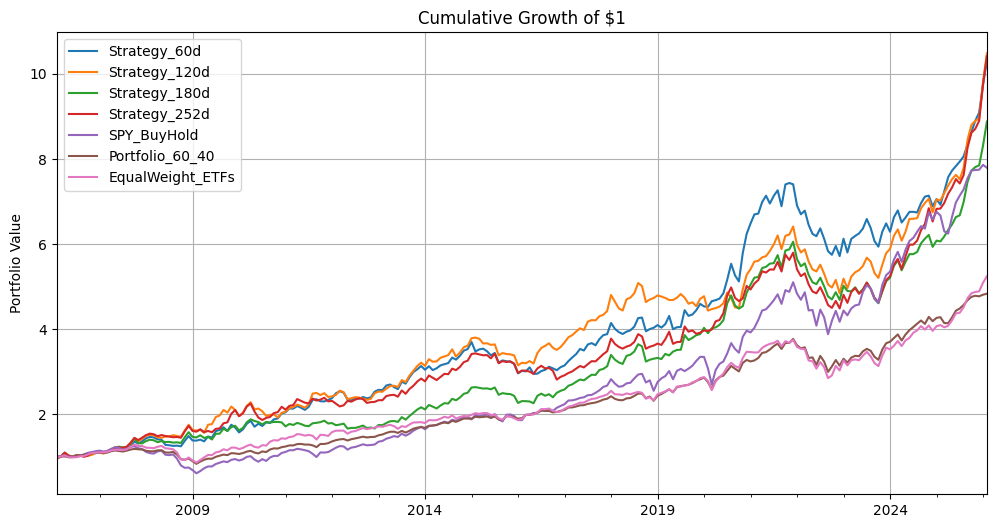

In [15]:
cumulative = (1 + all_returns).cumprod()

cumulative.plot(title="Cumulative Growth of $1")
plt.ylabel("Portfolio Value")
plt.show()

## 14. Compute full-sample performance metrics

In this section, I calculate basic performance metrics for each strategy and benchmark over the full available sample.

### What this section is doing
I compute:
- CAGR
- annualized volatility
- Sharpe
- max drawdown
- Calmar

### Why this matters
This provides the first quantitative comparison of the baseline strategy variants.

In [16]:
metrics_full = pd.DataFrame({col: compute_metrics(all_returns[col]) for col in all_returns.columns}).T
metrics_full

,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar
Strategy_60d,0.123161,0.126813,0.971206,-0.230909,0.533378
Strategy_120d,0.124122,0.128584,0.965302,-0.244820,0.506995
Strategy_180d,0.114866,0.121534,0.945130,-0.238701,0.481210
Strategy_252d,0.123780,0.127458,0.971143,-0.225921,0.547890
SPY_BuyHold,0.107651,0.150318,0.716154,-0.507848,0.211975
Portfolio_60_40,0.081618,0.092047,0.886706,-0.294596,0.277051
EqualWeight_ETFs,0.086011,0.111162,0.773748,-0.328486,0.261841


## 15. Compute train / validation / test metrics

In this section, I evaluate each return series separately across train, validation, and test periods.

### What this section is doing
This allows me to see whether performance is:
- strong only in-sample
- stable across periods
- still believable out of sample

### Why this matters
This is one of the most important parts of the notebook. A strategy that looks great only on the full sample but weakens badly in validation or test is less trustworthy.

In [17]:
def metrics_by_split(returns_df, train_start, train_end, valid_start, valid_end, test_start, test_end):
    results = []

    for col in returns_df.columns:
        train = returns_df.loc[train_start:train_end, col]
        valid = returns_df.loc[valid_start:valid_end, col]
        test = returns_df.loc[test_start:test_end, col]

        train_metrics = compute_metrics(train)
        valid_metrics = compute_metrics(valid)
        test_metrics = compute_metrics(test)

        row = {
            "Series": col,
            "Train Sharpe": train_metrics.get("Sharpe"),
            "Valid Sharpe": valid_metrics.get("Sharpe"),
            "Test Sharpe": test_metrics.get("Sharpe"),
            "Train CAGR": train_metrics.get("CAGR"),
            "Valid CAGR": valid_metrics.get("CAGR"),
            "Test CAGR": test_metrics.get("CAGR"),
            "Train MaxDD": train_metrics.get("Max Drawdown"),
            "Valid MaxDD": valid_metrics.get("Max Drawdown"),
            "Test MaxDD": test_metrics.get("Max Drawdown"),
        }
        results.append(row)

    return pd.DataFrame(results).set_index("Series")

metrics_split = metrics_by_split(
    all_returns,
    TRAIN_START, TRAIN_END,
    VALID_START, VALID_END,
    TEST_START, TEST_END
)

metrics_split

,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Series,,,,,,,,,
Strategy_60d,1.182983,0.311848,1.044502,0.152080,0.033659,0.139817,-0.150569,-0.202726,-0.230909
Strategy_120d,1.132896,0.613173,0.928628,0.154989,0.069800,0.117333,-0.157982,-0.171450,-0.244820
Strategy_180d,0.866930,0.617893,1.225022,0.108669,0.071566,0.147721,-0.115345,-0.143657,-0.238701
Strategy_252d,1.084243,0.243556,1.197780,0.141756,0.026146,0.159143,-0.171149,-0.179685,-0.225921
SPY_BuyHold,0.504523,0.617763,1.027044,0.077103,0.071234,0.168471,-0.507848,-0.135321,-0.239272
Portfolio_60_40,0.847070,0.796940,0.991116,0.074661,0.051013,0.107945,-0.294596,-0.068587,-0.205075
EqualWeight_ETFs,0.667682,0.598757,0.993079,0.078026,0.044881,0.119903,-0.328486,-0.087708,-0.239394


## 16. Inspect monthly weights for one baseline strategy

In this section, I inspect the monthly portfolio weights for one of the shared momentum windows.

### What this section is doing
I display the weight table for the 120-day strategy as an example.

### Why this matters
This helps verify that the portfolio construction logic behaves as intended:
- selected assets get positive weights
- fallback weight goes to IEF when necessary
- weights sum to 1

In [18]:
weight_check = shifted_weight_tables[120].copy()
weight_check["WeightSum"] = weight_check.sum(axis=1)

display(weight_check.head(12))

,EEM,EFA,GLD,IEF,IWM,QQQ,SPY,TLT,WeightSum
2006-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2006-02-28,0.499743,0.000000,0.500257,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-03-31,0.489035,0.000000,0.510965,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-04-28,0.455195,0.000000,0.544805,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-05-31,0.507230,0.000000,0.492770,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-06-30,0.000000,0.644127,0.355873,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-07-31,0.000000,0.618969,0.381031,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-08-31,0.000000,0.576166,0.423834,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-09-29,0.000000,0.573737,0.426263,0.000000,0.0,0.0,0.000000,0.000000,1.0
2006-10-31,0.000000,0.000000,0.000000,0.626635,0.0,0.0,0.000000,0.373365,1.0


## 17. Select the strongest shared baseline candidate

In this section, I identify which shared momentum window looks strongest before moving to more advanced tuning.

### What this section is doing
I compare the strategy variants using validation and test results, not just full-sample performance.

### Why this matters
The goal is not simply to choose the version with the highest in-sample result. I want the version that looks strongest and most believable across validation and test.

In [19]:
strategy_only_split = metrics_split.loc[[c for c in metrics_split.index if c.startswith("Strategy_")]].copy()
strategy_only_split.sort_values(["Valid Sharpe", "Test Sharpe"], ascending=False)

,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Series,,,,,,,,,
Strategy_180d,0.866930,0.617893,1.225022,0.108669,0.071566,0.147721,-0.115345,-0.143657,-0.238701
Strategy_120d,1.132896,0.613173,0.928628,0.154989,0.069800,0.117333,-0.157982,-0.171450,-0.244820
Strategy_60d,1.182983,0.311848,1.044502,0.152080,0.033659,0.139817,-0.150569,-0.202726,-0.230909
Strategy_252d,1.084243,0.243556,1.197780,0.141756,0.026146,0.159143,-0.171149,-0.179685,-0.225921


## 18. Save backtest artifacts

In this section, I save the key backtest outputs for later notebooks.

### What this section is doing
I save:
- strategy returns
- benchmark returns
- all return series
- full-sample metrics
- split metrics

### Why this matters
This keeps the workflow reproducible and makes later comparison notebooks easier to build.

In [20]:
strategy_returns.to_csv(PROCESSED_DIR / "strategy_returns_shared_baseline.csv")
benchmark_returns.to_csv(PROCESSED_DIR / "benchmark_returns.csv")
all_returns.to_csv(PROCESSED_DIR / "all_returns_shared_baseline.csv")
metrics_full.to_csv(PROCESSED_DIR / "metrics_full_shared_baseline.csv")
metrics_split.to_csv(PROCESSED_DIR / "metrics_split_shared_baseline.csv")

print("Saved backtest artifacts to:", PROCESSED_DIR.resolve())

Saved backtest artifacts to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


In [21]:
weight_tables[120].to_csv(PROCESSED_DIR / "shared_120d_target_weights.csv")
weight_tables[180].to_csv(PROCESSED_DIR / "shared_180d_target_weights.csv")
weight_tables[252].to_csv(PROCESSED_DIR / "shared_252d_target_weights.csv")

print("Saved shared target weight tables.")

Saved shared target weight tables.


## 19. Key takeaways from this notebook

At this stage, I have completed the first full backtest of the shared-parameter tactical ETF strategy.

### What I accomplished
- converted monthly signals into portfolio weights
- avoided look-ahead bias by shifting weights forward
- calculated realized strategy returns
- built benchmark comparisons
- measured performance over the full sample
- evaluated the strategy across train, validation, and test periods

### What I learned
This notebook shows whether the shared baseline strategy is promising enough to justify deeper research. It also helps identify which shared momentum window is the strongest candidate before moving to asset-class-level or ETF-level tuning.

### What comes next
The next research path can branch in two directions:
- asset-class-level tuning
- ETF-level tuning

Both should be compared against this shared baseline before deciding whether added complexity is truly worth it.